In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

In [22]:
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [23]:
df['job_month_number'] = df['job_posted_date'].dt.month
df['job_month_name'] = df['job_posted_date'].dt.month_name()

In [66]:
df_DA = df[df['job_title_short'] == 'Data Analyst']

In [67]:
df_DA_exploded = df_DA.explode('job_skills')

In [98]:
df_DA_pivot = df_DA_exploded.pivot_table(
    index='job_month_number',
    columns='job_skills',
    aggfunc='size',
    fill_value=0
)
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_pivot

job_skills,sql,excel,python,tableau,power bi,r,sas,powerpoint,word,sap,...,xamarin,mattermost,gtx,esquisse,chainer,capacitor,nuxt.js,msaccess,ovh,suse
job_month_number,,,,,,,,,,,,,,,,,,,,,
1,11336,8170,6606,5596,4285,3607,3830,1880,1778,1251,...,0,0,0,0,0,1,1,0,0,0
2,7947,5772,4751,3936,3307,2576,2634,1291,1235,954,...,0,0,0,0,0,0,0,0,0,0
3,7868,5675,4741,4051,3176,2650,2554,1266,1203,892,...,1,0,0,0,0,0,0,0,0,1
4,7553,5496,4557,3776,3106,2399,2598,1190,1177,947,...,0,0,0,0,0,0,0,0,1,0
5,6617,4773,4070,3245,2695,2093,1940,979,957,851,...,0,0,0,0,0,0,0,1,0,0
6,7584,5724,4707,3812,3275,2442,2174,1173,1237,987,...,0,0,0,0,0,0,0,0,0,0
7,7687,5513,4831,3928,3350,2444,2118,1096,1069,996,...,0,0,1,0,0,0,0,0,0,0
8,8823,6482,5576,4533,3859,2975,2560,1332,1298,1117,...,0,0,0,0,0,0,0,0,0,0
9,6829,4886,4229,3446,3118,2146,1880,944,945,852,...,0,1,0,0,0,0,0,0,0,0


In [94]:
df_DA_pivot = df_DA_pivot.drop('Total')

<Axes: xlabel='job_month_number'>

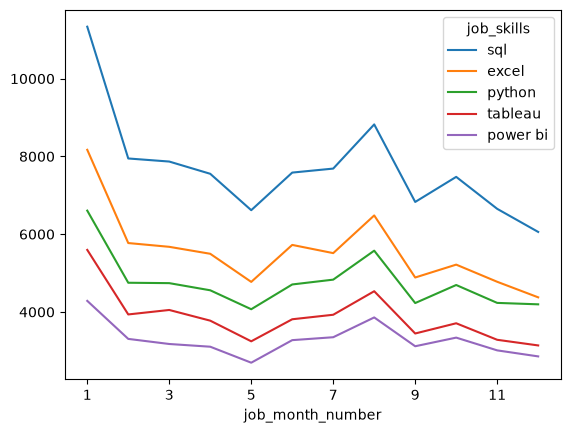

In [97]:
df_DA_pivot = df_DA_pivot.iloc[:, :5]
df_DA_pivot.plot(kind='line')